1. Implement a simple NN to classify handwritten digits from mnist dataset. Perform the following,

    *   Load and Preprocess
    *   Design NN with input layer, one hidden layer(128 neurons, ReLU), output layer(10 neurons, soft max)

    *   Train the model seperately using - SGD with momentum, Adagrad, RMS prop, Adam

    *   Keep all the hyper parameters same, except the optimizer
    *   Compare training accuracy, validation accuracy, training loss, validation loss

    *   Plot - accuracy Vs epochs, loss Vs epochs

    *   Identify which optimizer converges faster and justify your answer







In [7]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Load and preprocess data
# -------------------------------

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# -------------------------------
# Step 2: Build the Neural Network
# -------------------------------

def create_model():
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

# -------------------------------
# Step 3: Define Optimizers
# -------------------------------

optimizers = {
    "SGD_Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Adagrad": Adagrad(learning_rate=0.01),
    "RMSprop": RMSprop(learning_rate=0.001),
    "Adam": Adam(learning_rate=0.001)
}

histories = {}

# -------------------------------
# Step 4: Train models
# -------------------------------

for name, optimizer in optimizers.items():

    print(f"\nTraining with {name}")

    model = create_model()

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=128,
        verbose=1
    )

    histories[name] = history


Training with SGD_Momentum
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8504 - loss: 0.5437 - val_accuracy: 0.9162 - val_loss: 0.3014
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9170 - loss: 0.2917 - val_accuracy: 0.9312 - val_loss: 0.2467
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9321 - loss: 0.2408 - val_accuracy: 0.9402 - val_loss: 0.2160
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9418 - loss: 0.2053 - val_accuracy: 0.9487 - val_loss: 0.1877
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9499 - loss: 0.1789 - val_accuracy: 0.9536 - val_loss: 0.1696
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9559 - loss: 0.1584 - val_accuracy: 0.9592 - val_loss: 0.1553
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9610 - loss: 0.1418 - val_accuracy: 0.9613 - val_loss: 0.1448
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9642 - los

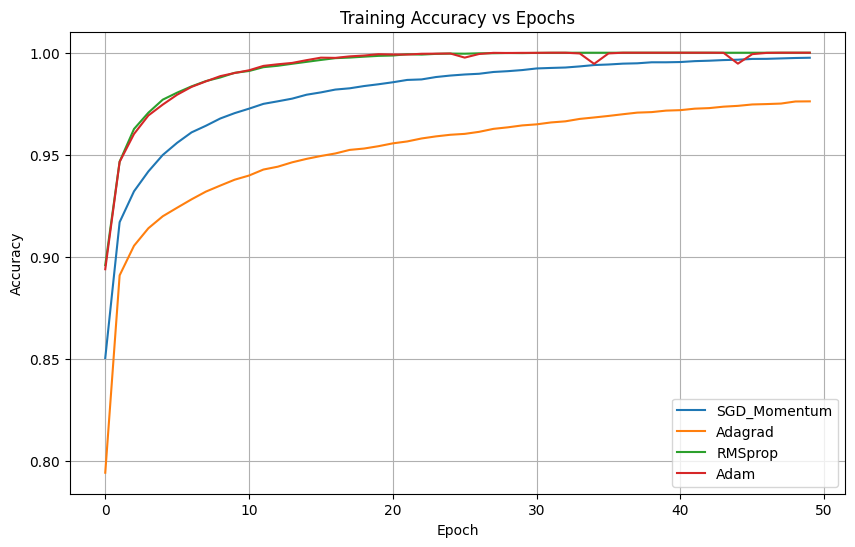

In [8]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['accuracy'], label=name)

plt.title("Training Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

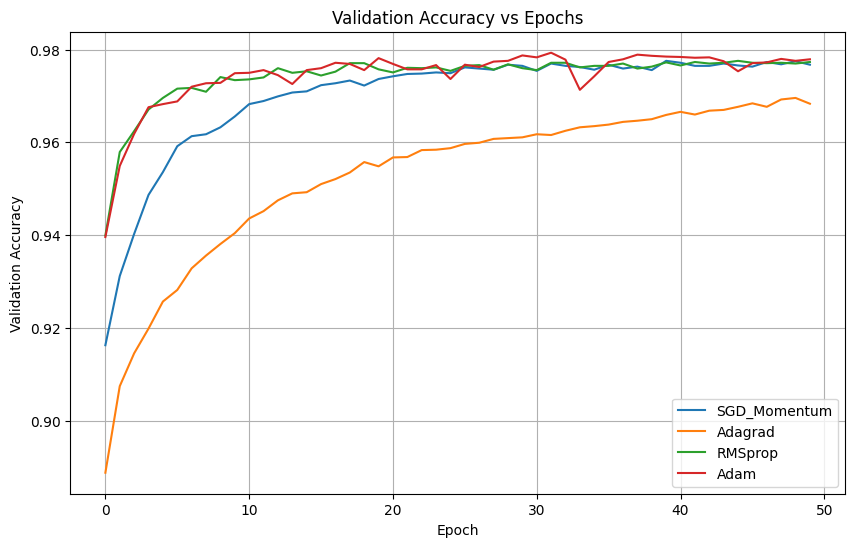

In [9]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

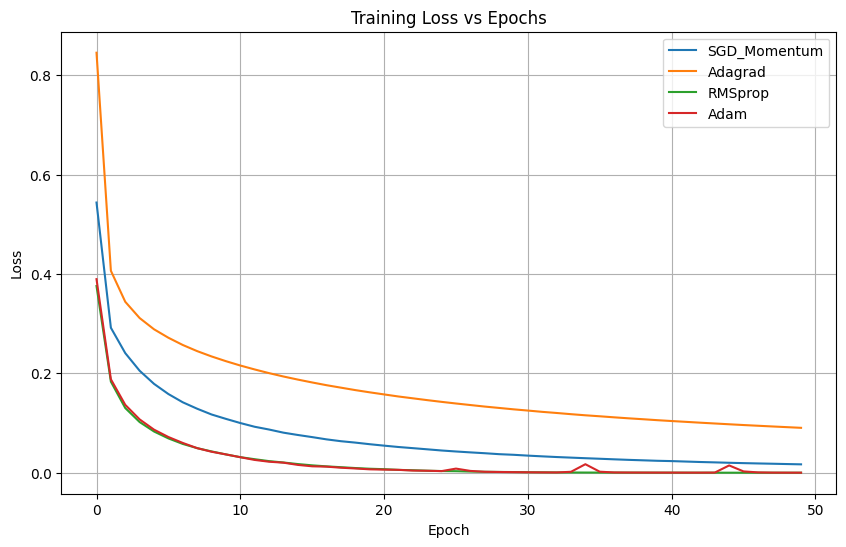

In [10]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['loss'], label=name)

plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

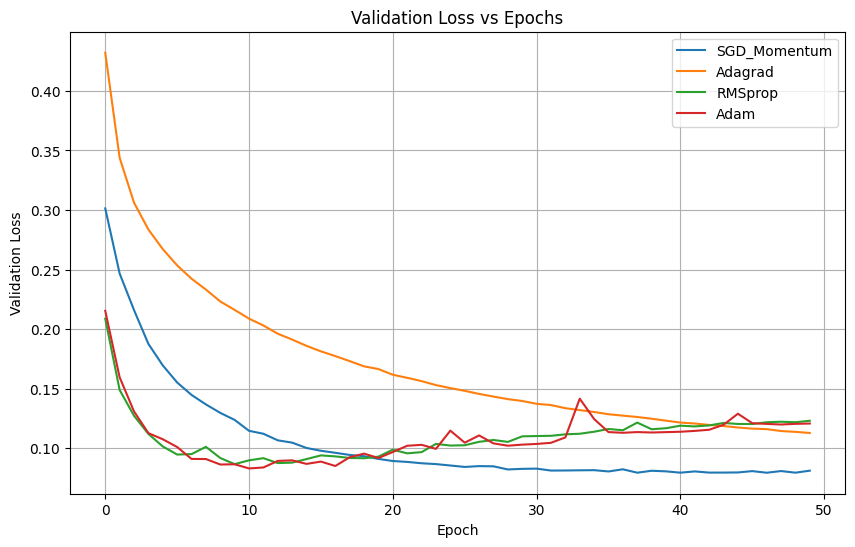

In [11]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=name)

plt.title("Validation Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
print("\nFinal Comparison\n")

print("{:<15} {:<15} {:<15} {:<15} {:<15}".format(
    "Optimizer",
    "Train Acc",
    "Val Acc",
    "Train Loss",
    "Val Loss"))

for name, history in histories.items():

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    print("{:<15} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f}".format(
        name,
        train_acc,
        val_acc,
        train_loss,
        val_loss
    ))


Final Comparison

Optimizer       Train Acc       Val Acc         Train Loss      Val Loss       
SGD_Momentum    0.9975          0.9768          0.0170          0.0813         
Adagrad         0.9762          0.9683          0.0905          0.1129         
RMSprop         1.0000          0.9773          0.0002          0.1232         
Adam            1.0000          0.9779          0.0002          0.1208         


2. Consider a dataset and train a LR model using batch GD, StGD, and minibatch(batch size =64) GD and measure the execution time, number of parameter update, final loss and based on your observation, identify the most suitable optimizer for largescale dataset.


Comparison

Method         Time(sec)      Parameter Updates   Final Loss     
-----------------------------------------------------------------
Batch GD       0.0060         100                 0.25221        
SGD            0.6403         45500               0.04828        
Mini Batch     0.0178         800                 0.11348        


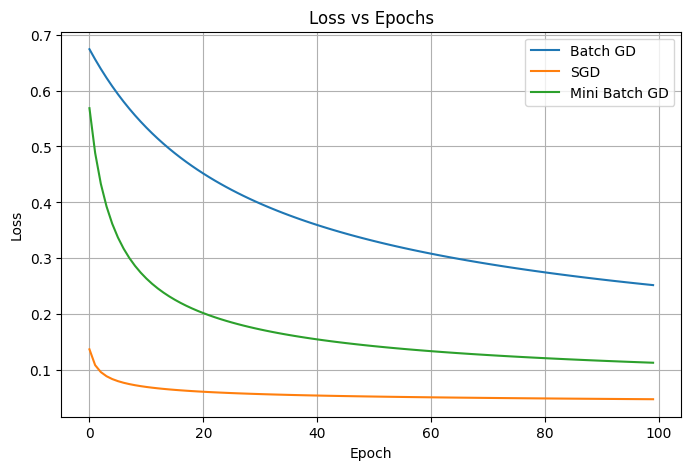

In [13]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ----------------------------
# Load Dataset
# ----------------------------

data = load_breast_cancer()

X = data.data
y = data.target

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ----------------------------
# Sigmoid Function
# ----------------------------

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ----------------------------
# Binary Cross Entropy Loss
# ----------------------------

def compute_loss(y, y_pred):
    epsilon = 1e-10
    return -np.mean(
        y*np.log(y_pred+epsilon) +
        (1-y)*np.log(1-y_pred+epsilon)
    )

# ----------------------------
# Logistic Regression Training
# ----------------------------

def train_gd(X, y, method="batch", lr=0.01, epochs=100, batch_size=64):

    m, n = X.shape

    weights = np.zeros(n)
    bias = 0

    losses = []
    updates = 0

    start = time.time()

    for epoch in range(epochs):

        if method == "batch":

            z = np.dot(X, weights) + bias
            pred = sigmoid(z)

            dw = (1/m) * np.dot(X.T, (pred-y))
            db = (1/m) * np.sum(pred-y)

            weights -= lr*dw
            bias -= lr*db

            updates += 1

        elif method == "sgd":

            for i in range(m):

                xi = X[i:i+1]
                yi = y[i:i+1]

                pred = sigmoid(np.dot(xi, weights)+bias)

                dw = np.dot(xi.T, (pred-yi)).flatten()
                db = np.sum(pred-yi)

                weights -= lr*dw
                bias -= lr*db

                updates += 1

        elif method == "mini":

            for i in range(0, m, batch_size):

                xb = X[i:i+batch_size]
                yb = y[i:i+batch_size]

                pred = sigmoid(np.dot(xb, weights)+bias)

                dw = (1/len(xb))*np.dot(xb.T, (pred-yb))
                db = (1/len(xb))*np.sum(pred-yb)

                weights -= lr*dw
                bias -= lr*db

                updates += 1

        pred = sigmoid(np.dot(X, weights)+bias)
        loss = compute_loss(y, pred)
        losses.append(loss)

    end = time.time()

    return losses, end-start, updates

# ----------------------------
# Train Models
# ----------------------------

batch_loss, batch_time, batch_updates = train_gd(
    X_train, y_train,
    method="batch"
)

sgd_loss, sgd_time, sgd_updates = train_gd(
    X_train, y_train,
    method="sgd"
)

mini_loss, mini_time, mini_updates = train_gd(
    X_train, y_train,
    method="mini",
    batch_size=64
)

# ----------------------------
# Print Results
# ----------------------------

print("\nComparison\n")

print("{:<15}{:<15}{:<20}{:<15}".format(
    "Method",
    "Time(sec)",
    "Parameter Updates",
    "Final Loss"
))

print("-"*65)

print("{:<15}{:<15.4f}{:<20}{:<15.5f}".format(
    "Batch GD",
    batch_time,
    batch_updates,
    batch_loss[-1]
))

print("{:<15}{:<15.4f}{:<20}{:<15.5f}".format(
    "SGD",
    sgd_time,
    sgd_updates,
    sgd_loss[-1]
))

print("{:<15}{:<15.4f}{:<20}{:<15.5f}".format(
    "Mini Batch",
    mini_time,
    mini_updates,
    mini_loss[-1]
))

# ----------------------------
# Plot Loss
# ----------------------------

plt.figure(figsize=(8,5))

plt.plot(batch_loss,label="Batch GD")
plt.plot(sgd_loss,label="SGD")
plt.plot(mini_loss,label="Mini Batch GD")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")

plt.legend()
plt.grid(True)

plt.show()

3. Implement a Generative Adversarial Network (GAN) using TensorFlow/Keras to generate handwritten digit images from the MNIST dataset.Include

   *  Loading and preprocessing the MNIST dataset

    * Designing the Generator network.

    * Designing the Discriminator network

    * Training the GAN for a specified number of epochs.

    * Generating and displaying at least 16 synthetic handwritten digit images.

    * Expected Output

          Trained GAN model.
          Generated handwritten digits.
          Loss values of Generator and Discriminator.
          Plot the Generator loss.
          Plot the Discriminator loss.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 784)            │       803,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,486,352 (5.67 MB)

 Trainable params: 1,486,352 (5.67 MB)

...

 Total params: 1,460,225 (5.57 MB)

 Trainable params: 1,460,225 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1/100 | D Loss: 4.5234 | G Loss: 0.0079
Epoch 2/100 | D Loss: 4.9967 | G Loss: 0.0040
Epoch 3/100 | D Loss: 5.2448 | G Loss: 0.0027
Epoch 4/100 | D Loss: 5.4074 | G Loss: 0.0020
Epoch 5/100 | D Loss: 5.5273 | G Loss: 0.0016
Epoch 6/100 | D Loss: 5.6204 | G Loss: 0.0013
Epoch 7/100 | D Loss: 5.6957 | G Loss: 0.0011
Epoch 8/100 | D Loss: 5.7589 | G Loss: 0.0010
Epoch 9/100 | D Loss: 5.8134 | G Loss: 0.0009
Epoch 10/100 | D Loss: 5.8614 | G Loss: 0.0008
Epoch 11/100 | D Loss: 5.9030 | G Loss: 0.0007
Epoch 12/100 | D Loss: 5.9390 | G Loss: 0.0007
Epoch 13/100 | D Loss: 5.9707 | G Loss: 0.0006
Epoch 14/100 | D Loss: 5.9988 | G Loss: 0.0006
Epoch 15/100 | D Loss: 6.0240 | G Loss: 0.0005
Epoch 16/100 | D Loss: 6.0466 | G Loss: 0.0005
Epoch 17/100 | D Loss: 6.0672 | G Loss: 0.0005
Epoch 18/100 | D Loss: 6.0859 | G Loss: 0.0005
Epoch 19/100 | D Loss: 6.1028 | G Loss: 0.0004
Epoch 20/100 | D Loss: 6.1183 | G Loss: 0.0004
Epoch 21/100 | D Loss: 6.1324 | G Loss: 0.0004
Epoch 22/100 | D Loss:

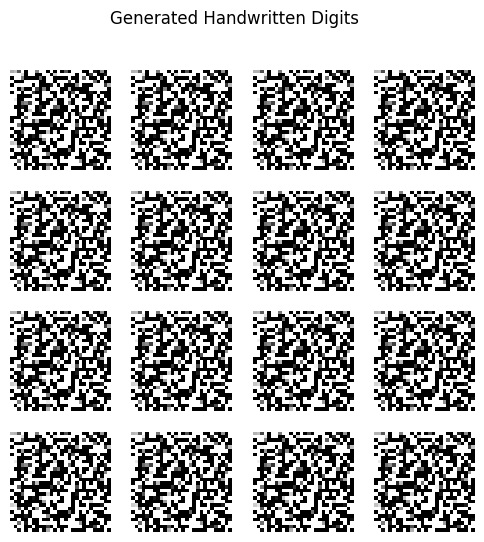

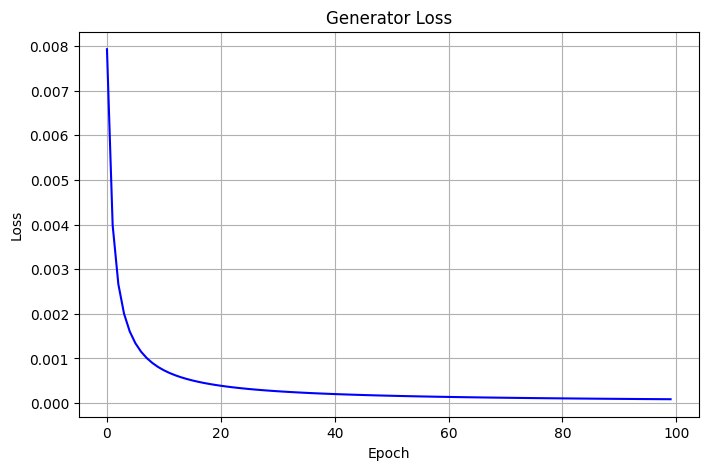

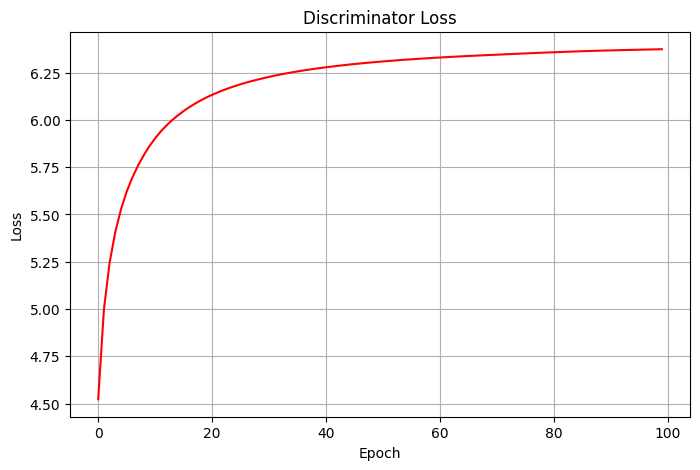


Final Generator Loss : 8.5546e-05
Final Discriminator Loss : 6.373534


In [14]:
# ==========================================
# Import Libraries
# ==========================================

import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Load and Preprocess MNIST Dataset
# ==========================================

(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images to [-1,1]
x_train = (x_train.astype("float32") - 127.5) / 127.5

# Reshape to 784-dimensional vectors
x_train = x_train.reshape(x_train.shape[0], 784)

BUFFER_SIZE = 60000
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# ==========================================
# Generator Network
# ==========================================

noise_dim = 100

generator = Sequential([
    Dense(256, input_dim=noise_dim),
    LeakyReLU(alpha=0.2),

    Dense(512),
    LeakyReLU(alpha=0.2),

    Dense(1024),
    LeakyReLU(alpha=0.2),

    Dense(784, activation='tanh')
])

generator.summary()

# ==========================================
# Discriminator Network
# ==========================================

discriminator = Sequential([
    Dense(1024, input_dim=784),
    LeakyReLU(alpha=0.2),

    Dense(512),
    LeakyReLU(alpha=0.2),

    Dense(256),
    LeakyReLU(alpha=0.2),

    Dense(1, activation='sigmoid')
])

discriminator.summary()

# ==========================================
# Compile Discriminator
# ==========================================

optimizer = Adam(0.0002, beta_1=0.5)

discriminator.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# Build GAN
# ==========================================

discriminator.trainable = False

gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    optimizer=optimizer,
    loss='binary_crossentropy'
)

# ==========================================
# Training Parameters
# ==========================================

epochs = 100
generator_losses = []
discriminator_losses = []

# ==========================================
# Training Loop
# ==========================================

for epoch in range(epochs):

    for real_images in dataset:

        batch_size = real_images.shape[0]

        # -------------------------
        # Train Discriminator
        # -------------------------

        noise = np.random.normal(0, 1, (batch_size, noise_dim))

        fake_images = generator.predict(noise, verbose=0)

        real_labels = np.ones((batch_size,1))
        fake_labels = np.zeros((batch_size,1))

        d_loss_real = discriminator.train_on_batch(real_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # -------------------------
        # Train Generator
        # -------------------------

        noise = np.random.normal(0,1,(batch_size, noise_dim))

        valid_labels = np.ones((batch_size,1))

        g_loss = gan.train_on_batch(noise, valid_labels)

    generator_losses.append(g_loss)
    discriminator_losses.append(d_loss[0])

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss[0]:.4f} | G Loss: {g_loss:.4f}")

# ==========================================
# Generate Synthetic Images
# ==========================================

noise = np.random.normal(0,1,(16,noise_dim))

generated_images = generator.predict(noise)

generated_images = generated_images.reshape(16,28,28)

generated_images = (generated_images + 1)/2

# ==========================================
# Display Generated Images
# ==========================================

plt.figure(figsize=(6,6))

for i in range(16):

    plt.subplot(4,4,i+1)
    plt.imshow(generated_images[i], cmap='gray')
    plt.axis("off")

plt.suptitle("Generated Handwritten Digits")
plt.show()

# ==========================================
# Plot Generator Loss
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(generator_losses, color='blue')

plt.title("Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

# ==========================================
# Plot Discriminator Loss
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(discriminator_losses, color='red')

plt.title("Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

# ==========================================
# Final Loss Values
# ==========================================

print("\nFinal Generator Loss :", generator_losses[-1])
print("Final Discriminator Loss :", discriminator_losses[-1])